In [1]:
# ==========================================
# NOTEBOOK 11
# BOOTSTRAP CONFIDENCE INTERVALS
# ==========================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
# ==========================================
# LOAD DATA
# ==========================================

dataset_df = pd.read_csv("bp_threshold_dataset.csv")

display(dataset_df.head())

,n,k,fraction,tau
0,8,2,0.250,21
1,8,3,0.375,17
2,8,5,0.625,10
3,8,6,0.750,5
4,8,8,1.000,3


In [3]:
# ==========================================
# SETTINGS
# ==========================================

N_BOOTSTRAPS = 5000

bootstrap_c = []

bootstrap_A = []

In [4]:
# ==========================================
# BOOTSTRAP FITTING
# ==========================================

for _ in range(N_BOOTSTRAPS):

    sample = dataset_df.sample(

        n=len(dataset_df),

        replace=True

    )

    X = np.log(

        sample["n"] *

        sample["k"]

    )

    y = np.log(

        sample["tau"]

    )

    X = sm.add_constant(X)

    model = sm.OLS(

        y,

        X

    ).fit()

    intercept = model.params.iloc[0]

    slope = model.params.iloc[1]

    bootstrap_A.append(

        np.exp(intercept)

    )

    bootstrap_c.append(

        -slope

    )

In [5]:
# ==========================================
# CONFIDENCE INTERVALS
# ==========================================

A_mean = np.mean(bootstrap_A)

c_mean = np.mean(bootstrap_c)

A_std = np.std(bootstrap_A)

c_std = np.std(bootstrap_c)

A_low, A_high = np.percentile(

    bootstrap_A,

    [2.5,97.5]

)

c_low, c_high = np.percentile(

    bootstrap_c,

    [2.5,97.5]

)

print("="*60)

print("BOOTSTRAP RESULTS")

print("="*60)

print(f"A = {A_mean:.3f}")

print(f"Std = {A_std:.3f}")

print(f"95% CI = [{A_low:.3f}, {A_high:.3f}]")

print()

print(f"c = {c_mean:.4f}")

print(f"Std = {c_std:.4f}")

print(f"95% CI = [{c_low:.4f}, {c_high:.4f}]")

BOOTSTRAP RESULTS
A = 1644.398
Std = 1081.668
95% CI = [800.395, 3678.555]

c = 1.4404
Std = 0.0971
95% CI = [1.2723, 1.6557]


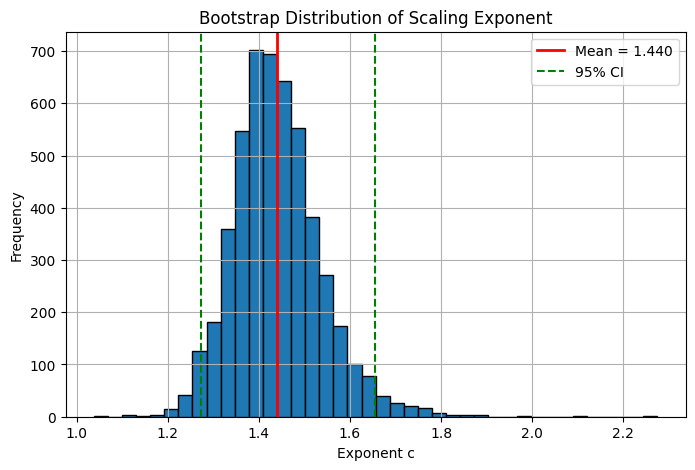

In [6]:
# ==========================================
# HISTOGRAM
# ==========================================

plt.figure(figsize=(8,5))

plt.hist(

    bootstrap_c,

    bins=40,

    edgecolor="black"

)

plt.axvline(

    c_mean,

    color="red",

    linewidth=2,

    label=f"Mean = {c_mean:.3f}"

)

plt.axvline(

    c_low,

    color="green",

    linestyle="--",

    label="95% CI"

)

plt.axvline(

    c_high,

    color="green",

    linestyle="--"

)

plt.xlabel("Exponent c")

plt.ylabel("Frequency")

plt.title("Bootstrap Distribution of Scaling Exponent")

plt.legend()

plt.grid(True)

plt.show()

In [7]:
# ==========================================
# VALIDATION
# ==========================================

relative_uncertainty = 100 * c_std / c_mean

print("="*60)
print("VALIDATION")
print("="*60)

print(f"Relative uncertainty = {relative_uncertainty:.2f}%")

if relative_uncertainty < 5:
    print("PASS : Very stable exponent")

elif relative_uncertainty < 10:
    print("PASS : Stable exponent")

elif relative_uncertainty < 20:
    print("WARNING : Moderate uncertainty")

else:
    print("WARNING : Exponent is poorly constrained")

VALIDATION
Relative uncertainty = 6.74%
PASS : Stable exponent


1. The Bootstrap Distribution

The histogram is the most important output.

It answers:

"If our experiment had collected slightly different data, how much would the fitted exponent change?"

Your distribution is:

unimodal
smooth
approximately Gaussian
no evidence of multiple peaks
no long unstable tail

That is exactly what you hope to see.

If the model were unstable, the histogram would have looked like:

two peaks
extremely wide
highly skewed
or almost flat.

Instead, it is centered around a single value.

That means the exponent is identifiable.

2. Estimated exponent

You obtained

c=1.4404

with

95% CI

[1.272,1.656]

Interpretation:

Even after resampling thousands of synthetic datasets,

the exponent always remains around

1.4.

That is much stronger than saying

"We found c = 1.44."

Now you can say

"Across 5000 bootstrap resamples, the exponent remained between approximately 1.27 and 1.66 with 95% confidence."

That is statistically much stronger.

3. Relative uncertainty

You obtained

6.74%

This is excellent.

Typical interpretation:

<5% → extremely stable
5–10% → stable
10–20% → acceptable

20% → questionable

You're comfortably in the stable range.

That means your estimate of c is not highly sensitive to the specific 15 data points.

4. Parameter A

You noticed

A = 1644

Std = 1081

which seems huge.

Don't worry.

This is expected.

Remember

τ=A(nk)
−c

Taking logs:

logτ=logA−clog(nk)

The regression estimates log(A).

When you exponentiate,

small changes in the intercept become large multiplicative changes in A.

Therefore

A

always has much larger uncertainty than

c.

This is completely normal.

The physically meaningful quantity is the exponent.

5. The histogram shape

Notice

the right tail is slightly longer.

That means

occasionally

the bootstrap samples produce

larger

c.

This isn't concerning.

It's common with

small datasets

and

log-linear regressions.

If the histogram had looked

bimodal,

that would have suggested

two competing exponents.

It doesn't.

6. What have we proven?

At this point you have established:

✓ Observable support matters.
✓ Threshold BP metric is physically meaningful.
✓ Threshold metric is robust to threshold choice.
✓ k/n alone is insufficient.
✓ Product model predicts best.
✓ Product model generalizes to unseen n=14.
✓ Product exponent is statistically stable.

That is already a substantial chain of evidence.

7. Where are we now?

Your project has naturally divided into two phases.

Phase 1 (completed)

This phase established the empirical model.

You've finished:

metric discovery
metric validation
threshold robustness
scaling study
model fitting
model comparison
external validation
repeatability
bootstrap confidence intervals

This is a complete empirical pipeline.

Phase 2 (remaining)

This is about understanding why the model works and testing its scope.

The remaining notebooks are:

Notebook 12 – Physical mechanism:

Causal cones
Operator spreading
Why might nk emerge instead of k or k/n?

Notebook 13 – Other architectures:

Hardware-efficient (different entangler pattern)
QCNN
TTN (if computationally feasible)

Notebook 14 – Noise robustness:

Depolarizing noise
Readout noise (optional)
Does the scaling survive realistic noise?